In [1]:
!pip install biopython numpy pandas scikit-learn xgboost networkx matplotlib seaborn transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 71.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from collections import Counter
import itertools
import random

random.seed(42)
np.random.seed(42)

In [4]:

def generate_dna_sequence(length, gc_content):
    """Generate a random DNA sequence with a target GC-content."""
    at_prob = (1 - gc_content) / 2
    gc_prob = gc_content / 2
    bases = np.random.choice(
        ['A', 'T', 'G', 'C'],
        size=length,
        p=[at_prob, at_prob, gc_prob, gc_prob]
    )
    return ''.join(bases)

def create_dataset(seq_length=500, n_per_class=500):
    sequences = []
    labels = []

    # Species A: high GC (e.g., Streptomyces bacteria)
    for _ in range(n_per_class):
        sequences.append(generate_dna_sequence(seq_length, gc_content=0.70))
        labels.append(0)

    # Species B: low GC (e.g., Plasmodium parasite)
    for _ in range(n_per_class):
        sequences.append(generate_dna_sequence(seq_length, gc_content=0.25))
        labels.append(1)

    return sequences, labels

print("=" * 65)
print("PROJECT 1: DNA Sequence Classification with k-mer + Random Forest")
print("=" * 65)

sequences, labels = create_dataset(seq_length=500, n_per_class=500)
print(f"\nGenerated {len(sequences)} sequences ({len(sequences)//2} per class)")
print(f"Sequence length: 500 bp")
print(f"Species A (label 0): High GC (~70%) — e.g., Streptomyces")
print(f"Species B (label 1): Low GC (~25%) — e.g., Plasmodium")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: k-mer feature extraction
# ─────────────────────────────────────────────────────────────────────────────

def extract_kmer_features(sequence, k=4):
    """
    Count occurrences of each possible k-mer in the sequence.
    Returns a vector of length 4^k.
    """
    kmers = [sequence[i:i+k] for i in range(len(sequence) - k + 1)]
    counter = Counter(kmers)
    all_kmers = [''.join(p) for p in itertools.product('ATGC', repeat=k)]
    feature_vector = np.array([counter.get(kmer, 0) for kmer in all_kmers], dtype=float)
    # Normalize to frequency (fraction of total k-mers)
    feature_vector /= feature_vector.sum()
    return feature_vector

k = 4  # tetranucleotide frequency
print(f"\nExtracting {k}-mer features (4^{k} = {4**k} features per sequence)...")

X = np.array([extract_kmer_features(seq, k=k) for seq in sequences])
y = np.array(labels)

print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Train / Test split
# ─────────────────────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")


PROJECT 1: DNA Sequence Classification with k-mer + Random Forest

Generated 1000 sequences (500 per class)
Sequence length: 500 bp
Species A (label 0): High GC (~70%) — e.g., Streptomyces
Species B (label 1): Low GC (~25%) — e.g., Plasmodium

Extracting 4-mer features (4^4 = 256 features per sequence)...
Feature matrix shape: (1000, 256)
Label vector shape: (1000,)

Train set: 750 samples
Test set:  250 samples



Training Random Forest classifier...

──────────────────────────────────────────────────
  Test Accuracy:  1.0000
  ROC-AUC Score:  1.0000
──────────────────────────────────────────────────

Classification Report:
                     precision    recall  f1-score   support

Species A (High GC)       1.00      1.00      1.00       125
 Species B (Low GC)       1.00      1.00      1.00       125

           accuracy                           1.00       250
          macro avg       1.00      1.00      1.00       250
       weighted avg       1.00      1.00      1.00       250


Top 10 most discriminative 4-mers:
  1. AAAT — importance: 0.0887
  2. AATA — importance: 0.0619
  3. TATT — importance: 0.0601
  4. TTAA — importance: 0.0532
  5. CCGG — importance: 0.0515
  6. AATT — importance: 0.0479
  7. TTTA — importance: 0.0470
  8. ATTA — importance: 0.0402
  9. TTAT — importance: 0.0397
  10. ATAA — importance: 0.0364

[Saved] project1_confusion_roc.png

PROJECT 1 COMPLETE


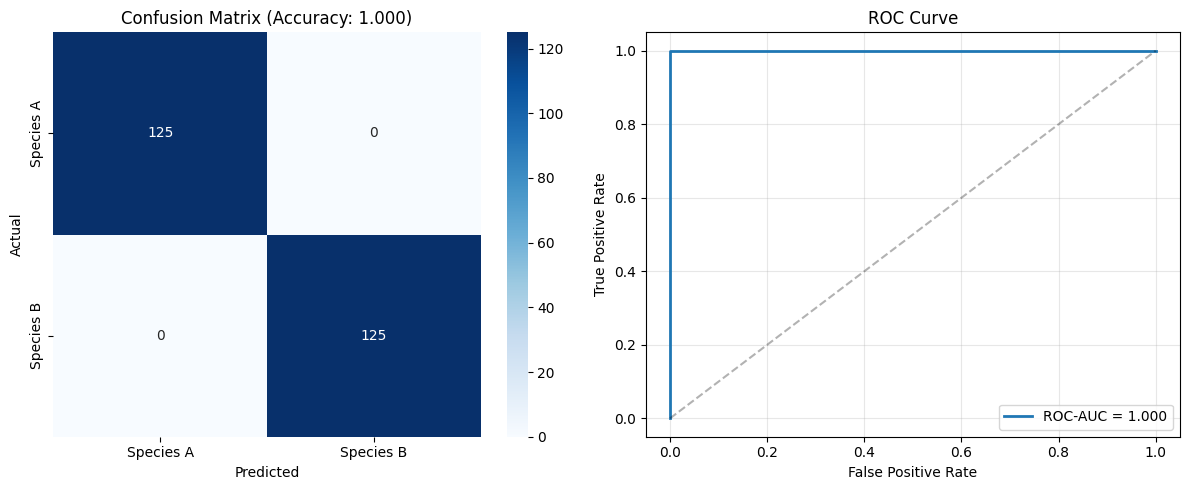

In [5]:

print("\nTraining Random Forest classifier...")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Evaluate
# ─────────────────────────────────────────────────────────────────────────────

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"\n{'─' * 50}")
print(f"  Test Accuracy:  {accuracy:.4f}")
print(f"  ROC-AUC Score:  {roc_auc:.4f}")
print(f"{'─' * 50}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Species A (High GC)', 'Species B (Low GC)']))

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: Feature importance — which k-mers are most discriminative?
# ─────────────────────────────────────────────────────────────────────────────

all_kmers = [''.join(p) for p in itertools.product('ATGC', repeat=k)]
importances = rf.feature_importances_
top_n = 10
top_indices = np.argsort(importances)[::-1][:top_n]

print(f"\nTop {top_n} most discriminative {k}-mers:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}. {all_kmers[idx]} — importance: {importances[idx]:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: Visualization
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Species A', 'Species B'],
            yticklabels=['Species A', 'Species B'])
axes[0].set_title(f'Confusion Matrix (Accuracy: {accuracy:.3f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('project1_confusion_roc.png', dpi=150)
print("\n[Saved] project1_confusion_roc.png")
# plt.show()

print("\n" + "=" * 65)
print("PROJECT 1 COMPLETE")
print("=" * 65)

# ─────────────────────────────────────────────────────────────────────────────
# EXTENSIONS (for further exploration)
# ─────────────────────────────────────────────────────────────────────────────
#
# 1. Use real genomic data via Biopython Entrez:
#    from Bio import Entrez, SeqIO
#    Entrez.email = "your@email.com"
#    handle = Entrez.efetch(db="nucleotide", id="NC_000913", rettype="fasta")
#    record = SeqIO.read(handle, "fasta")
#
# 2. Try different k values (3, 5, 6) — trade-off: larger k = more features,
#    sparser data, need more samples
#
# 3. Try other classifiers: Logistic Regression, SVM, XGBoost
#
# 4. Apply to real problem: classify coding vs. non-coding DNA, or detect
#    horizontally transferred genes by anomalous k-mer signatures
#
# 5. Use reverse complement aware k-mers (collapse palindromic pairs)